## This notebook plots a transect of the ADCP data 

#Station numbering for sanity: 
-> 1-14
-> 1 test
-> 2-3 Bremer Canyon
-> 4 Deep CTD
-> 5, 6, 7, 8, 9 KI
-> 10, 11, 12, 13, 14 BU

In [7]:
# Import packages
import os              # For file path handling
import time            # For sleep during retry logic
import shutil          # For copying downloaded content
import requests        # For HTTP downloads
import urllib3         # For disabling SSL warnings
import numpy as np     # For logical operations and array handling
import pandas as pd    # For reading and manipulating the GDAC index
from datetime import datetime  # For date filtering
import xarray as xr 
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import cmocean
import gsw as gsw
import glob
from scipy.io import loadmat

In [2]:
os.chdir(r'C:\Users\nribeiro\OneDrive - University of Tasmania\CAPSTAN SHARED DRIVE\current\adcp\ladcp\processing\processed') #Will need to change this 

In [3]:
def load_ladcp(pattern="*.mat", sort_by=None):
    """
    Load LADCP MATLAB profiles into an xarray Dataset.

    Parameters
    ----------
    pattern : str
        File pattern, e.g. "*.mat"

    sort_by : str or None
        Sort stations by:
        - "lon" = west to east
        - "lat" = south to north

    Returns
    -------
    xarray.Dataset
    """

    # Find files
    files = sorted(glob.glob(pattern))

    if len(files) == 0:
        raise FileNotFoundError(
            f"No files found matching {pattern}"
        )

    print(f"Found {len(files)} LADCP files")


    # Store profiles
    profiles = []


    # ----------------------------------
    # Load each MATLAB file
    # ----------------------------------
    for filename in files:

        mat = loadmat(
            filename,
            squeeze_me=True,
            struct_as_record=False
        )

        dr = mat["dr"]

        profile = {
            "filename": filename,

            "depth": np.asarray(dr.z).squeeze(),

            "U": np.asarray(dr.u).squeeze(),

            "V": np.asarray(dr.v).squeeze(),

            "lat": float(dr.lat),

            "lon": float(dr.lon),
        }


        # Vertical velocity
        if hasattr(dr, "w"):
            profile["W"] = np.asarray(dr.w).squeeze()

        elif hasattr(dr, "w_shear_method"):
            profile["W"] = np.asarray(
                dr.w_shear_method
            ).squeeze()

        else:
            profile["W"] = np.full_like(
                profile["depth"],
                np.nan
            )


        profiles.append(profile)



    # ----------------------------------
    # Create common depth axis
    # ----------------------------------

    all_depths = np.concatenate(
        [
            p["depth"]
            for p in profiles
        ]
    )

    depth = np.unique(all_depths)
    depth.sort()


    n_depth = len(depth)
    n_station = len(profiles)


    # Empty arrays
    U = np.full(
        (n_depth, n_station),
        np.nan
    )

    V = np.full(
        (n_depth, n_station),
        np.nan
    )

    W = np.full(
        (n_depth, n_station),
        np.nan
    )


    lat = np.zeros(n_station)
    lon = np.zeros(n_station)

    filenames = []



    # ----------------------------------
    # Put profiles onto depth grid
    # ----------------------------------

    for i, p in enumerate(profiles):

        depth_index = np.searchsorted(
            depth,
            p["depth"]
        )

        U[depth_index, i] = p["U"]

        V[depth_index, i] = p["V"]

        W[depth_index, i] = p["W"]

        lat[i] = p["lat"]

        lon[i] = p["lon"]

        filenames.append(
            p["filename"]
        )



    # ----------------------------------
    # Create xarray Dataset
    # ----------------------------------

    ds = xr.Dataset(

        data_vars={

            "U": (
                ["depth", "station"],
                U,
                {
                    "units": "m s-1",
                    "long_name": "eastward velocity"
                }
            ),

            "V": (
                ["depth", "station"],
                V,
                {
                    "units": "m s-1",
                    "long_name": "northward velocity"
                }
            ),

            "W": (
                ["depth", "station"],
                W,
                {
                    "units": "m s-1",
                    "long_name": "vertical velocity"
                }
            ),
        },


        coords={

            "depth": (
                "depth",
                depth,
                {
                    "units": "m"
                }
            ),

            "station": np.arange(n_station),

            "lat": (
                "station",
                lat
            ),

            "lon": (
                "station",
                lon
            ),

            "filename": (
                "station",
                filenames
            )
        }
    )


    # ----------------------------------
    # Sort geographically
    # ----------------------------------

    if sort_by in ["lon", "lat"]:

        ds = ds.sortby(sort_by)


    return ds

In [9]:
ladcp = load_ladcp("*.mat")

Found 12 LADCP files


In [10]:
ladcp.lon.values

array([119.72269, 119.62009, 134.1281 , 136.03093, 136.02334, 136.01575,
       136.00807, 140.99764, 141.16745, 141.14735,   0.     , 141.10198])

In [11]:
## the Bonney stations are 10,11,12,13,14. 13 is missing, I asked DAP why but waiting on response
ladcp.filename.values

array(['002.mat', '003.mat', '004.mat', '006.mat', '007.mat', '008.mat',
       '009.mat', '010.mat', '011.mat', '012.mat', '013.mat', '014.mat'],
      dtype='<U7')

In [12]:
#After sorting, reset the station coordinate because all has to be monotonic to work:

ladcp = ladcp.sortby("lon")
ladcp = ladcp.assign_coords(station=np.arange(ladcp.sizes["station"]))



In [13]:
#check, knowing that geographically the only stations I am plotting are the last 4 because one is missing:
ladcp.station


<xarray.DataArray 'station' (station: 12)> Size: 96B
array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
Coordinates:
  * station   (station) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
    lat       (station) float64 96B 0.0 -34.61 -34.72 ... -38.76 -38.62 -38.58
    lon       (station) float64 96B 0.0 119.6 119.7 134.1 ... 141.1 141.1 141.2
    filename  (station) <U7 336B '013.mat' '003.mat' ... '012.mat' '011.mat'

In [14]:
ladcp

<xarray.Dataset> Size: 190kB
Dimensions:   (depth: 653, station: 12)
Coordinates:
  * depth     (depth) uint16 1kB 8 16 24 32 40 48 ... 5192 5200 5208 5216 5224
  * station   (station) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
    lat       (station) float64 96B 0.0 -34.61 -34.72 ... -38.76 -38.62 -38.58
    lon       (station) float64 96B 0.0 119.6 119.7 134.1 ... 141.1 141.1 141.2
    filename  (station) <U7 336B '013.mat' '003.mat' ... '012.mat' '011.mat'
Data variables:
    U         (depth, station) float64 63kB 0.3541 0.1648 0.6571 ... nan nan nan
    V         (depth, station) float64 63kB -0.1217 -0.04832 0.2519 ... nan nan
    W         (depth, station) float64 63kB -0.01372 -0.0141 ... nan nan

In [37]:
#plot only las4
last4 = ladcp.isel(station=slice(-5, None))

In [38]:
## I would like to plot distance between stations rather than lat lon
import numpy as np
from scipy.spatial.distance import cdist


def add_distance(ds):
    """
    Add cumulative distance along transect (km)
    from lat/lon station positions.
    """

    # Extract coordinates
    lat = ds.lat.values
    lon = ds.lon.values

    # Convert degrees to approximate km
    R = 6371  # Earth radius km

    lat_rad = np.deg2rad(lat)
    lon_rad = np.deg2rad(lon)

    # Haversine distance between consecutive stations
    distances = []

    for i in range(len(lat)-1):

        dlat = lat_rad[i+1] - lat_rad[i]
        dlon = lon_rad[i+1] - lon_rad[i]

        a = (
            np.sin(dlat/2)**2
            +
            np.cos(lat_rad[i])
            * np.cos(lat_rad[i+1])
            * np.sin(dlon/2)**2
        )

        c = 2 * np.arctan2(
            np.sqrt(a),
            np.sqrt(1-a)
        )

        distances.append(R*c)


    # cumulative distance
    distance = np.insert(
        np.cumsum(distances),
        0,
        0
    )


    # add to dataset
    ds = ds.assign_coords(
        distance=(
            "station",
            distance
        )
    )

    return ds

In [39]:
last4 = add_distance(last4)

ValueError: The input coordinate is not sorted in increasing order along axis 0. This can lead to unexpected results. Consider calling the `sortby` method on the input DataArray. To plot data with categorical axes, consider using the `heatmap` function from the `seaborn` statistical plotting library.

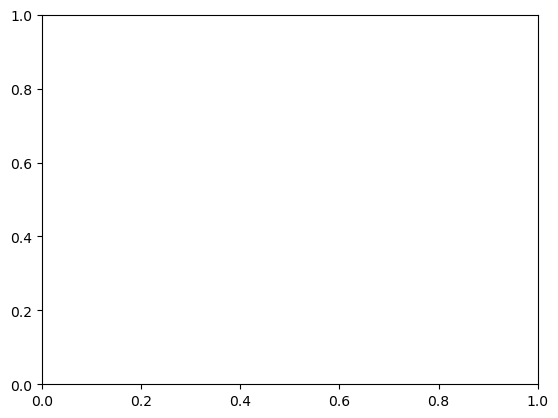

In [40]:
last4.V.plot(
    x="lat",
    y="depth",
    yincrease=False,
    cmap="RdBu_r"
)

In [41]:
#check
last4[["lat", "lon", "distance"]]

<xarray.Dataset> Size: 300B
Dimensions:   (station: 5)
Coordinates:
  * station   (station) int64 40B 7 8 9 10 11
    lat       (station) float64 40B -36.37 -38.87 -38.76 -38.62 -38.58
    lon       (station) float64 40B 136.0 141.0 141.1 141.1 141.2
    distance  (station) float64 40B 0.0 518.4 533.8 550.7 554.8
    filename  (station) <U7 140B '006.mat' '010.mat' ... '012.mat' '011.mat'
Data variables:
    *empty*

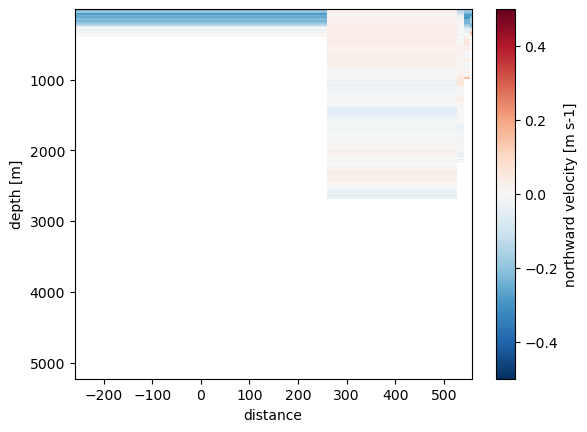

In [42]:
last4.V.plot(
    x="distance",
    y="depth",
    yincrease=False,
    cmap="RdBu_r",
    vmin=-0.5,
    vmax=0.5
)

In [29]:
V = (
    last4.V
    .swap_dims({"station":"distance"})
    .sortby("distance")
)


distance_new = np.linspace(
    V.distance.min().item(),
    V.distance.max().item(),
    100
)

depth_new = np.arange(0,3001,10)


V_smooth = (
    V
    .interp(depth=depth_new)
    .interp(distance=distance_new)
)

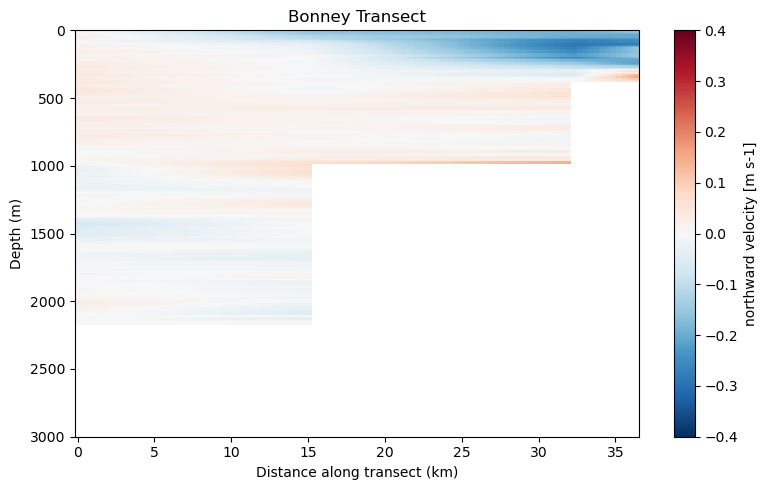

In [30]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))

V_smooth.plot(
    ax=ax,
    x="distance",
    y="depth",
    yincrease=False,
    cmap="RdBu_r",
    vmin=-0.4,
    vmax=0.4
)

ax.set_ylim(3000,0)
ax.set_xlabel("Distance along transect (km)")
ax.set_ylabel("Depth (m)")
ax.set_title("Bonney Transect")
plt.tight_layout()

In [31]:
## Contour plot style - V

In [32]:
import numpy as np
import matplotlib.pyplot as plt

V = last4.V.values
depth = last4.depth.values
distance = last4.distance.values

In [33]:
depth_mask = depth <= 3000

V = V[depth_mask, :]
depth = depth[depth_mask]

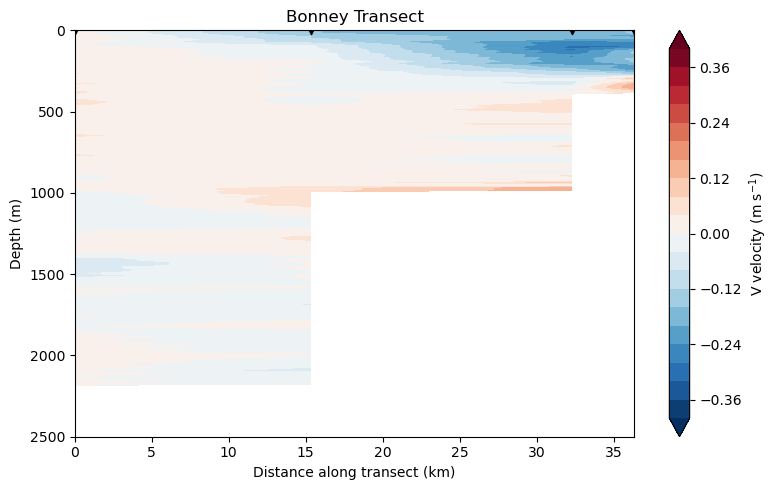

In [34]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))

# Colour levels
levels = np.linspace(-0.4, 0.4, 21)

# Filled contours
cf = ax.contourf(
    distance,
    depth,
    V,
    levels=levels,
    cmap="RdBu_r",
    extend="both"
)

## Contour lines
#cs = ax.contour(
#    distance,
#    depth,
#    V,
#    levels=np.linspace(-0.4, 0.4, 11),
#    colors="k",
#    linewidths=0.5
#)

## Add contour labels
#ax.clabel(
#    cs,
#    inline=True,
#    fontsize=8,
#    fmt="%.1f"
#)

# Invert depth axis
ax.invert_yaxis()

# Limits and labels
ax.set_ylim(2500, 0)

ax.set_xlabel("Distance along transect (km)")
ax.set_ylabel("Depth (m)")
ax.set_title("Bonney Transect")

# Colour bar
cbar = plt.colorbar(cf, ax=ax)
cbar.set_label("V velocity (m s$^{-1}$)")

# Add station positions
ax.scatter(
    distance,
    np.zeros_like(distance),
    marker="v",
    color="k",
    zorder=10
)

plt.savefig(
    r"C:\Users\nribeiro\OneDrive - University of Tasmania\IMOS Shared Docs\CAPSTAN 2025\CAPSTAN_HAB_work\Figures\LADCP_V_BonneySection.png",
    bbox_inches="tight"
)

plt.tight_layout()

In [92]:
## Contour plot style - U

In [97]:
import numpy as np
import matplotlib.pyplot as plt

U = last4.U.values
depth = last4.depth.values
distance = last4.distance.values

In [98]:
depth_mask = depth <= 3000

U = U[depth_mask, :]
depth = depth[depth_mask]

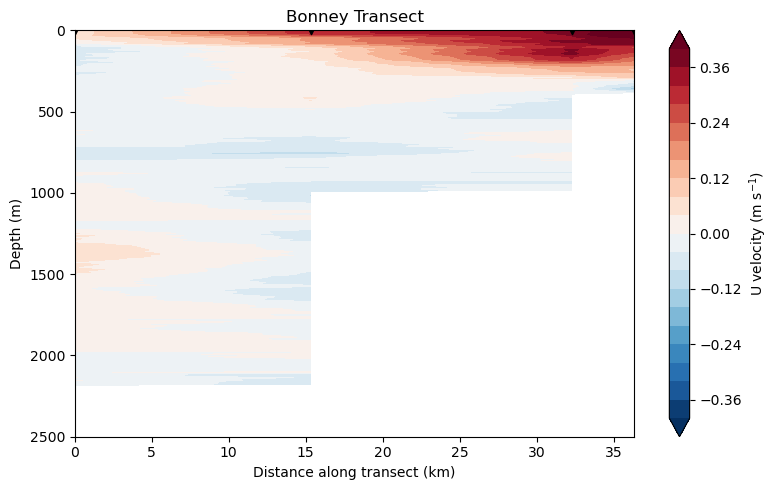

In [99]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))

# Colour levels
levels = np.linspace(-0.4, 0.4, 21)

# Filled contours
cf = ax.contourf(
    distance,
    depth,
    U,
    levels=levels,
    cmap="RdBu_r",
    extend="both"
)


# Invert depth axis
ax.invert_yaxis()

# Limits and labels
ax.set_ylim(2500, 0)

ax.set_xlabel("Distance along transect (km)")
ax.set_ylabel("Depth (m)")
ax.set_title("Bonney Transect")

# Colour bar
cbar = plt.colorbar(cf, ax=ax)
cbar.set_label("U velocity (m s$^{-1}$)")

# Add station positions
ax.scatter(
    distance,
    np.zeros_like(distance),
    marker="v",
    color="k",
    zorder=10
)

plt.savefig(
    r"C:\Users\nribeiro\OneDrive - University of Tasmania\IMOS Shared Docs\CAPSTAN 2025\CAPSTAN_HAB_work\Figures\LADCP_U_BonneySection.png",
    bbox_inches="tight"
)

plt.tight_layout()